In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("friction_formulation.csv")

# 1. 形状：多少行、多少列
print("shape:", df.shape)

# 2. 缺失值总数
print("缺失值总数:", df.isna().sum().sum())

# 3. 闭合校验：19个配方列之和
comp_cols = [c for c in df.columns
             if c not in ["batch_id", "press_temp_C", "press_pressure_MPa",
                          "press_time_min", "post_cure_temp_C", "wear_rate"]]
print("配方列数:", len(comp_cols))
print("闭合和范围: %.2f ~ %.2f" % (df[comp_cols].sum(axis=1).min(),
                                   df[comp_cols].sum(axis=1).max()))

df.head()

shape: (200, 25)
缺失值总数: 0
配方列数: 19
闭合和范围: 100.00 ~ 100.00


,batch_id,phenolic,phenolic_modified,aramid,ceramic_fiber,mineral_fiber,cellulose_fiber,graphite,MoS2,Sb2S3,...,CaCO3,mica,vermiculite,NBR_powder,friction_dust,press_temp_C,press_pressure_MPa,press_time_min,post_cure_temp_C,wear_rate
0,F001,3.578,11.357,5.965,3.627,3.343,7.663,8.557,0.224,0.769,...,10.105,3.448,1.051,6.841,1.914,164.428,21.503,14.570,171.207,0.217
1,F002,14.183,0.853,3.752,3.594,8.488,4.612,11.777,1.730,0.872,...,4.430,8.327,7.154,1.363,5.905,157.616,13.743,14.034,189.459,0.298
2,F003,11.111,3.602,0.367,2.497,7.412,2.738,13.296,0.683,1.807,...,8.208,4.857,1.090,6.546,1.861,167.741,21.392,11.902,193.830,0.453
3,F004,6.143,10.447,0.609,2.168,4.568,4.680,2.651,3.126,3.061,...,8.584,6.500,16.576,10.942,3.323,172.049,18.511,10.963,185.539,0.963
4,F005,6.996,3.381,2.085,0.857,13.161,4.043,8.088,1.345,3.238,...,4.003,5.695,2.845,0.552,12.338,166.158,15.501,14.273,176.353,0.639


Matplotlib is building the font cache; this may take a moment.


count    200.000
mean       0.670
std        0.520
min        0.086
25%        0.363
50%        0.546
75%        0.811
max        4.545

偏度 skewness: 3.135
log后偏度: 0.063


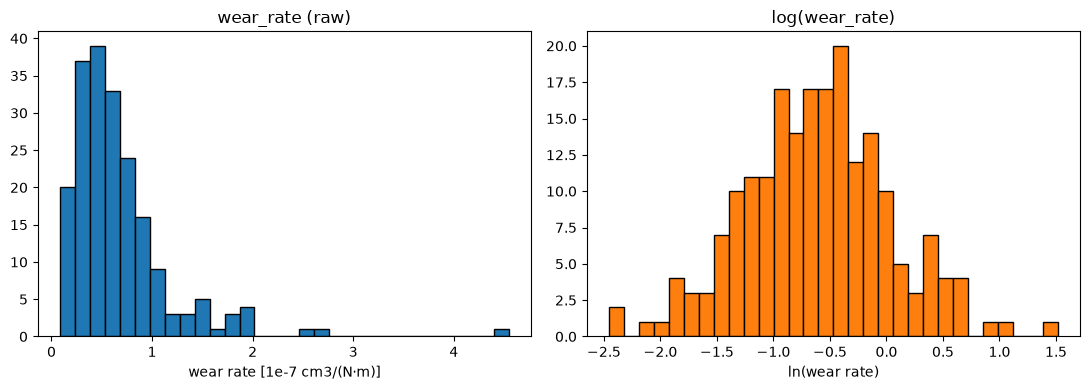

In [2]:
import matplotlib.pyplot as plt

y = df["wear_rate"]

print(y.describe().round(3).to_string())
print("\n偏度 skewness:", round(y.skew(), 3))
print("log后偏度:", round(np.log(y).skew(), 3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(y, bins=30, edgecolor="k")
axes[0].set_title("wear_rate (raw)")
axes[0].set_xlabel("wear rate [1e-7 cm3/(N·m)]")

axes[1].hist(np.log(y), bins=30, edgecolor="k", color="tab:orange")
axes[1].set_title("log(wear_rate)")
axes[1].set_xlabel("ln(wear rate)")

plt.tight_layout()
plt.show()

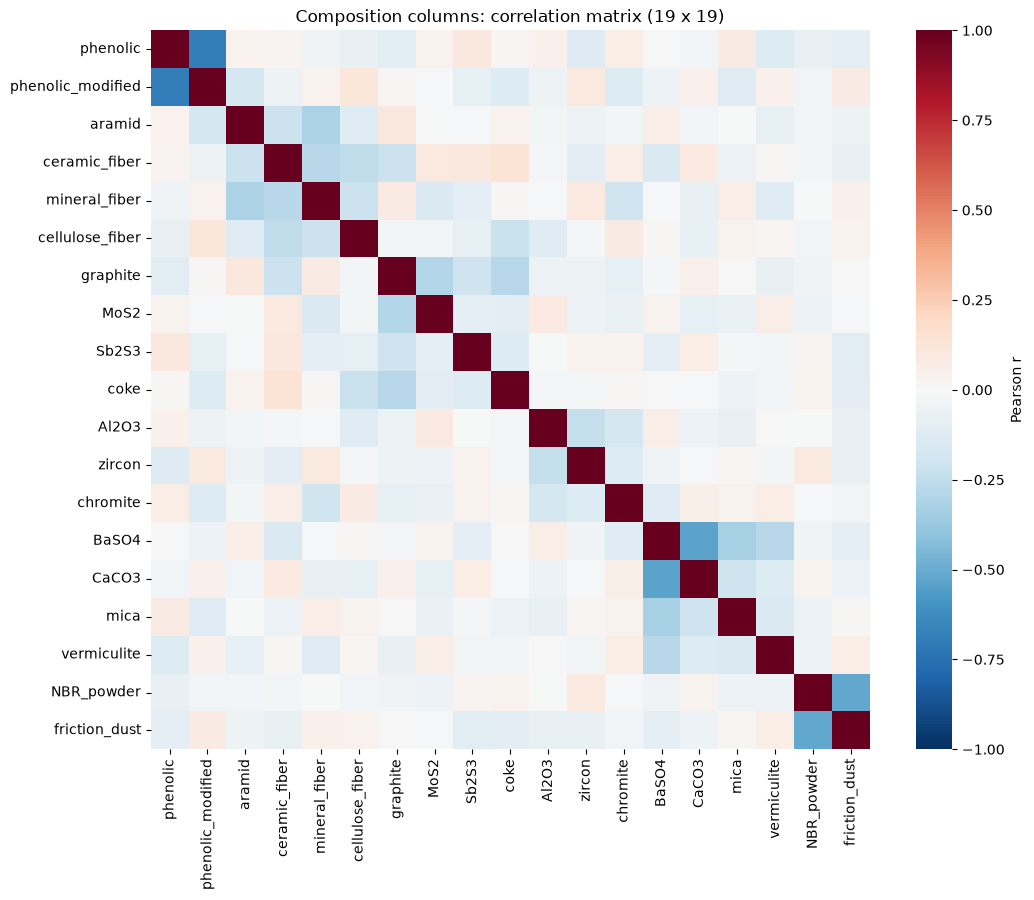

每列 vs 其余列之和 的相关系数：
phenolic            -1.0
vermiculite         -1.0
mica                -1.0
CaCO3               -1.0
BaSO4               -1.0
chromite            -1.0
zircon              -1.0
Al2O3               -1.0
NBR_powder          -1.0
coke                -1.0
MoS2                -1.0
graphite            -1.0
cellulose_fiber     -1.0
mineral_fiber       -1.0
ceramic_fiber       -1.0
aramid              -1.0
phenolic_modified   -1.0
Sb2S3               -1.0
friction_dust       -1.0


In [3]:
df["log_wear"] = np.log(df["wear_rate"])

# 配方列之间的相关系数矩阵
corr = df[comp_cols].corr()

import seaborn as sns
plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, annot=False, cbar_kws={"label": "Pearson r"})
plt.title("Composition columns: correlation matrix (19 x 19)")
plt.tight_layout()
plt.show()

# 关键诊断：每一列与"其余18列之和"的相关性
others_sum_corr = {}
for c in comp_cols:
    others = df[comp_cols].drop(columns=c).sum(axis=1)
    others_sum_corr[c] = df[c].corr(others)

print("每列 vs 其余列之和 的相关系数：")
print(pd.Series(others_sum_corr).round(3).sort_values().to_string())

各特征 与 log_wear 的 Pearson 相关系数（升序）：
aramid               -0.698
graphite             -0.350
post_cure_temp_C     -0.222
mica                 -0.108
chromite             -0.089
BaSO4                -0.088
NBR_powder           -0.086
press_pressure_MPa   -0.038
press_temp_C         -0.032
press_time_min       -0.030
Sb2S3                -0.023
phenolic             -0.008
zircon               -0.006
coke                 -0.004
CaCO3                 0.029
cellulose_fiber       0.073
MoS2                  0.095
ceramic_fiber         0.150
vermiculite           0.177
phenolic_modified     0.206
mineral_fiber         0.225
friction_dust         0.229
Al2O3                 0.306


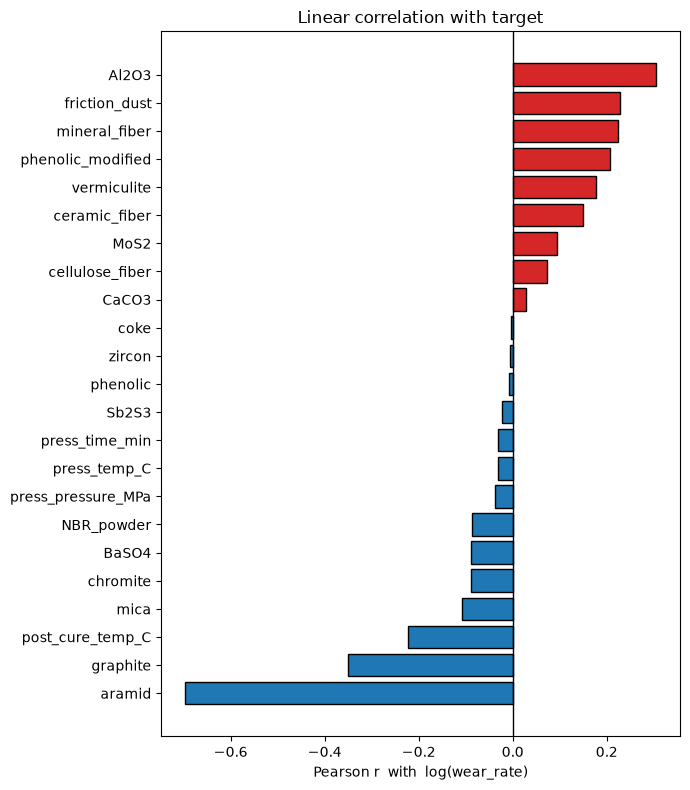

In [4]:
feat_cols = comp_cols + ["press_temp_C", "press_pressure_MPa",
                         "press_time_min", "post_cure_temp_C"]

r_y = df[feat_cols].corrwith(df["log_wear"]).sort_values()
print("各特征 与 log_wear 的 Pearson 相关系数（升序）：")
print(r_y.round(3).to_string())

plt.figure(figsize=(7, 8))
colors = ["tab:blue" if v < 0 else "tab:red" for v in r_y]
plt.barh(r_y.index, r_y.values, color=colors, edgecolor="k")
plt.axvline(0, color="k", lw=1)
plt.xlabel("Pearson r  with  log(wear_rate)")
plt.title("Linear correlation with target")
plt.tight_layout()
plt.show()

binder_total 与 log_wear 的 Pearson r: 0.253
对比 —— phenolic 单独: -0.008


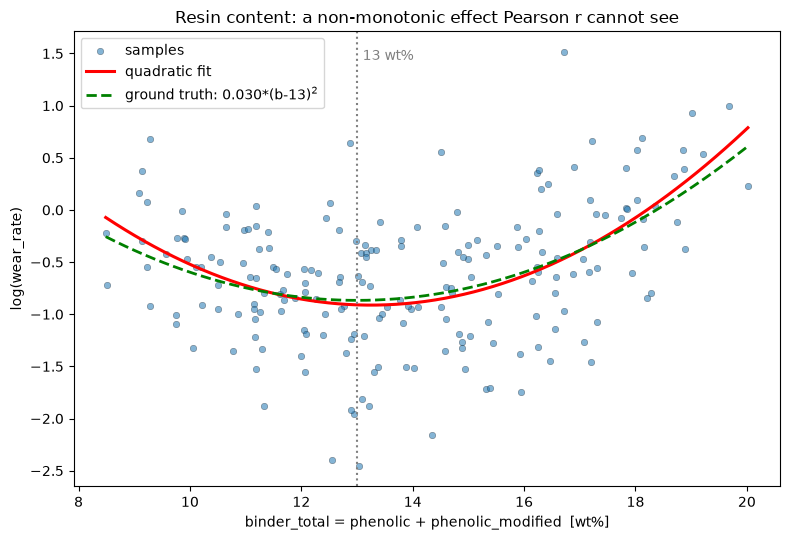


二次拟合的极小值点: 13.25 wt%  (真值 13.00)


In [5]:
# 领域知识：机理作用于"树脂总量"，不是两种酚醛各自
df["binder_total"] = df["phenolic"] + df["phenolic_modified"]

print("binder_total 与 log_wear 的 Pearson r:",
      round(df["binder_total"].corr(df["log_wear"]), 3))
print("对比 —— phenolic 单独:",
      round(df["phenolic"].corr(df["log_wear"]), 3))

x = df["binder_total"]
y = df["log_wear"]

# 二次多项式拟合（承认它是弯的）
coef = np.polyfit(x, y, 2)
xs = np.linspace(x.min(), x.max(), 200)
ys = np.polyval(coef, xs)

# 真值曲线（只有你知道）：0.030*(b-13)^2，加个常数好对齐
truth = 0.030 * (xs - 13.0) ** 2 + (y.mean() - 0.030 * ((x - 13.0) ** 2).mean())

plt.figure(figsize=(8, 5.5))
plt.scatter(x, y, s=22, alpha=0.55, edgecolor="k", linewidth=0.3, label="samples")
plt.plot(xs, ys, "r-", lw=2.2, label="quadratic fit")
plt.plot(xs, truth, "g--", lw=2.0, label="ground truth: 0.030*(b-13)$^2$")
plt.axvline(13.0, color="gray", ls=":", lw=1.5)
plt.text(13.1, y.max()*0.95, "13 wt%", color="gray")
plt.xlabel("binder_total = phenolic + phenolic_modified  [wt%]")
plt.ylabel("log(wear_rate)")
plt.title("Resin content: a non-monotonic effect Pearson r cannot see")
plt.legend()
plt.tight_layout()
plt.show()

# 拟合出的极小值点在哪
print("\n二次拟合的极小值点: %.2f wt%%  (真值 13.00)" % (-coef[1] / (2 * coef[0])))